## 正則化項

### Ridge

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.metrics import mean_squared_error

In [2]:
df = pd.read_csv("../data/Hitters.csv")

In [3]:
df

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
0,293,66,1,30,29,14,1,293,66,1,30,29,14,A,E,446,33,20,NaN,A
1,315,81,7,24,38,39,14,3449,835,69,321,414,375,N,W,632,43,10,475.0,N
2,479,130,18,66,72,76,3,1624,457,63,224,266,263,A,W,880,82,14,480.0,A
3,496,141,20,65,78,37,11,5628,1575,225,828,838,354,N,E,200,11,3,500.0,N
4,321,87,10,39,42,30,2,396,101,12,48,46,33,N,E,805,40,4,91.5,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
317,497,127,7,65,48,37,5,2703,806,32,379,311,138,N,E,325,9,3,700.0,N
318,492,136,5,76,50,94,12,5511,1511,39,897,451,875,A,E,313,381,20,875.0,A
319,475,126,3,61,43,52,6,1700,433,7,217,93,146,A,W,37,113,7,385.0,A
320,573,144,9,85,60,78,8,3198,857,97,470,420,332,A,E,1314,131,12,960.0,A


In [4]:
df.describe()

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,PutOuts,Assists,Errors,Salary
count,322.000000,322.000000,322.000000,322.000000,322.000000,322.000000,322.000000,322.00000,322.000000,322.000000,322.000000,322.000000,322.000000,322.000000,322.000000,322.000000,263.000000
mean,380.928571,101.024845,10.770186,50.909938,48.027950,38.742236,7.444099,2648.68323,717.571429,69.490683,358.795031,330.118012,260.239130,288.937888,106.913043,8.040373,535.925882
std,153.404981,46.454741,8.709037,26.024095,26.166895,21.639327,4.926087,2324.20587,654.472627,86.266061,334.105886,333.219617,267.058085,280.704614,136.854876,6.368359,451.118681
min,16.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,19.00000,4.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,67.500000
25%,255.250000,64.000000,4.000000,30.250000,28.000000,22.000000,4.000000,816.75000,209.000000,14.000000,100.250000,88.750000,67.250000,109.250000,7.000000,3.000000,190.000000
50%,379.500000,96.000000,8.000000,48.000000,44.000000,35.000000,6.000000,1928.00000,508.000000,37.500000,247.000000,220.500000,170.500000,212.000000,39.500000,6.000000,425.000000
75%,512.000000,137.000000,16.000000,69.000000,64.750000,53.000000,11.000000,3924.25000,1059.250000,90.000000,526.250000,426.250000,339.250000,325.000000,166.000000,11.000000,750.000000
max,687.000000,238.000000,40.000000,130.000000,121.000000,105.000000,24.000000,14053.00000,4256.000000,548.000000,2165.000000,1659.000000,1566.000000,1378.000000,492.000000,32.000000,2460.000000


In [5]:
# 欠損値対応
df.dropna(inplace=True)
df.describe()

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,PutOuts,Assists,Errors,Salary
count,263.000000,263.000000,263.000000,263.000000,263.000000,263.000000,263.000000,263.000000,263.000000,263.000000,263.000000,263.000000,263.000000,263.000000,263.000000,263.000000,263.000000
mean,403.642586,107.828897,11.619772,54.745247,51.486692,41.114068,7.311787,2657.543726,722.186312,69.239544,361.220532,330.418251,260.266160,290.711027,118.760456,8.593156,535.925882
std,147.307209,45.125326,8.757108,25.539816,25.882714,21.718056,4.793616,2286.582929,648.199644,82.197581,331.198571,323.367668,264.055868,279.934575,145.080577,6.606574,451.118681
min,19.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,19.000000,4.000000,0.000000,2.000000,3.000000,1.000000,0.000000,0.000000,0.000000,67.500000
25%,282.500000,71.500000,5.000000,33.500000,30.000000,23.000000,4.000000,842.500000,212.000000,15.000000,105.500000,95.000000,71.000000,113.500000,8.000000,3.000000,190.000000
50%,413.000000,103.000000,9.000000,52.000000,47.000000,37.000000,6.000000,1931.000000,516.000000,40.000000,250.000000,230.000000,174.000000,224.000000,45.000000,7.000000,425.000000
75%,526.000000,141.500000,18.000000,73.000000,71.000000,57.000000,10.000000,3890.500000,1054.000000,92.500000,497.500000,424.500000,328.500000,322.500000,192.000000,13.000000,750.000000
max,687.000000,238.000000,40.000000,130.000000,121.000000,105.000000,24.000000,14053.000000,4256.000000,548.000000,2165.000000,1659.000000,1566.000000,1377.000000,492.000000,32.000000,2460.000000


In [6]:
# データの準備
y_col = 'Salary'
X = df.loc[:, df.columns!=y_col]
X

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,NewLeague
1,315,81,7,24,38,39,14,3449,835,69,321,414,375,N,W,632,43,10,N
2,479,130,18,66,72,76,3,1624,457,63,224,266,263,A,W,880,82,14,A
3,496,141,20,65,78,37,11,5628,1575,225,828,838,354,N,E,200,11,3,N
4,321,87,10,39,42,30,2,396,101,12,48,46,33,N,E,805,40,4,N
5,594,169,4,74,51,35,11,4408,1133,19,501,336,194,A,W,282,421,25,A
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
317,497,127,7,65,48,37,5,2703,806,32,379,311,138,N,E,325,9,3,N
318,492,136,5,76,50,94,12,5511,1511,39,897,451,875,A,E,313,381,20,A
319,475,126,3,61,43,52,6,1700,433,7,217,93,146,A,W,37,113,7,A
320,573,144,9,85,60,78,8,3198,857,97,470,420,332,A,E,1314,131,12,A


In [7]:
y = df[y_col]

In [8]:
# 標準化のために数値カラムのリストを作成
numeric_cols = X.select_dtypes(include=np.number).columns.to_list()

In [9]:
X.dtypes

AtBat        int64
Hits         int64
HmRun        int64
Runs         int64
RBI          int64
Walks        int64
Years        int64
CAtBat       int64
CHits        int64
CHmRun       int64
CRuns        int64
CRBI         int64
CWalks       int64
League         str
Division       str
PutOuts      int64
Assists      int64
Errors       int64
NewLeague      str
dtype: object

In [10]:
X

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,NewLeague
1,315,81,7,24,38,39,14,3449,835,69,321,414,375,N,W,632,43,10,N
2,479,130,18,66,72,76,3,1624,457,63,224,266,263,A,W,880,82,14,A
3,496,141,20,65,78,37,11,5628,1575,225,828,838,354,N,E,200,11,3,N
4,321,87,10,39,42,30,2,396,101,12,48,46,33,N,E,805,40,4,N
5,594,169,4,74,51,35,11,4408,1133,19,501,336,194,A,W,282,421,25,A
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
317,497,127,7,65,48,37,5,2703,806,32,379,311,138,N,E,325,9,3,N
318,492,136,5,76,50,94,12,5511,1511,39,897,451,875,A,E,313,381,20,A
319,475,126,3,61,43,52,6,1700,433,7,217,93,146,A,W,37,113,7,A
320,573,144,9,85,60,78,8,3198,857,97,470,420,332,A,E,1314,131,12,A


In [11]:
# ダミー変数 （数値カラム作成の後)
X = pd.get_dummies(X, drop_first=True)
X.head()

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,PutOuts,Assists,Errors,League_N,Division_W,NewLeague_N
1,315,81,7,24,38,39,14,3449,835,69,321,414,375,632,43,10,True,True,True
2,479,130,18,66,72,76,3,1624,457,63,224,266,263,880,82,14,False,True,False
3,496,141,20,65,78,37,11,5628,1575,225,828,838,354,200,11,3,True,False,True
4,321,87,10,39,42,30,2,396,101,12,48,46,33,805,40,4,True,False,True
5,594,169,4,74,51,35,11,4408,1133,19,501,336,194,282,421,25,False,True,False


In [12]:
# hold-out
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

# 標準化
scaler = StandardScaler()
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])

In [13]:
X_train

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,PutOuts,Assists,Errors,League_N,Division_W,NewLeague_N
275,0.374183,0.079339,0.759350,-0.036632,0.127298,-0.296460,-1.139596,-0.906175,-0.919988,-0.550834,-0.911932,-0.815974,-0.833650,-0.629885,0.644269,0.260164,False,True,False
134,-1.795062,-1.530461,-0.745509,-1.472432,-0.853766,-1.260217,0.390956,-0.925691,-0.935379,-0.663465,-0.898341,-0.740174,-0.783531,-0.535854,-0.769140,-1.203755,True,True,True
19,-1.904206,-1.684826,-0.398234,-1.552199,-1.180788,-1.308404,0.172306,-0.883803,-0.885785,-0.550834,-0.942512,-0.791856,-0.804414,-0.312965,-0.722249,-1.057363,True,True,True
140,1.322375,0.785006,2.495725,1.199751,2.702594,1.149175,-1.139596,-0.898559,-0.897756,-0.353731,-0.826988,-0.626474,-0.750119,0.094505,-0.842825,0.699339,False,True,False
99,0.121786,0.035235,0.412075,0.601501,-0.158845,-0.248272,-0.046344,-0.215961,-0.263296,-0.353731,-0.031910,-0.474874,0.039246,0.000473,-0.829427,-0.910971,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
309,1.322375,0.674745,-1.324301,1.558701,-0.894644,0.908236,-1.139596,-0.641514,-0.665178,-0.874647,-0.487211,-0.836647,-0.578881,0.028334,-0.789236,-0.032620,True,False,True
240,-0.921907,-0.692483,-0.745509,-0.794415,-0.894644,-0.392836,1.046907,1.118294,1.128755,-0.212942,0.970433,0.424390,0.644843,-0.800534,-0.266743,-0.910971,False,True,False
151,-1.740490,-1.486357,-0.861267,-1.153365,-1.221666,-1.067465,-1.139596,-1.092771,-1.077320,-0.762017,-1.017263,-0.940010,-0.892121,-0.918944,-0.494496,-1.057363,False,True,False
62,-1.160660,-1.155576,-1.324301,-1.113482,-1.466932,-1.452968,-0.702295,-0.699111,-0.731873,-0.874647,-0.776021,-0.853874,-0.800237,-0.581128,0.463406,0.552947,False,True,False


In [14]:
X_train.describe()

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,PutOuts,Assists,Errors
count,1.840000e+02,1.840000e+02,1.840000e+02,1.840000e+02,1.840000e+02,1.840000e+02,1.840000e+02,1.840000e+02,1.840000e+02,1.840000e+02,1.840000e+02,1.840000e+02,1.840000e+02,1.840000e+02,1.840000e+02,184.000000
mean,-1.882552e-16,-1.351576e-16,9.654113e-18,9.412760e-17,2.413528e-17,8.326673e-17,-9.171408e-17,-4.827057e-17,2.896234e-17,9.654113e-18,9.171408e-17,-2.413528e-17,-2.413528e-17,-2.413528e-17,8.688702e-17,0.000000
std,1.002729e+00,1.002729e+00,1.002729e+00,1.002729e+00,1.002729e+00,1.002729e+00,1.002729e+00,1.002729e+00,1.002729e+00,1.002729e+00,1.002729e+00,1.002729e+00,1.002729e+00,1.002729e+00,1.002729e+00,1.002729
min,-2.634109e+00,-2.368440e+00,-1.324301e+00,-2.190332e+00,-2.080097e+00,-1.983034e+00,-1.358246e+00,-1.210345e+00,-1.178218e+00,-8.887262e-01,-1.149776e+00,-1.050265e+00,-1.021594e+00,-1.016458e+00,-8.696190e-01,-1.350147
25%,-8.400484e-01,-7.641520e-01,-7.455091e-01,-7.944153e-01,-8.128886e-01,-7.301504e-01,-7.022951e-01,-7.907427e-01,-8.045538e-01,-6.669846e-01,-8.108485e-01,-7.513715e-01,-7.146184e-01,-6.168251e-01,-8.160301e-01,-0.764579
50%,5.698197e-02,-3.092083e-02,-2.824756e-01,-1.363403e-01,-1.588454e-01,-2.000843e-01,-2.649946e-01,-3.130670e-01,-3.308462e-01,-3.537306e-01,-3.326122e-01,-2.491963e-01,-3.220243e-01,-2.798795e-01,-4.911471e-01,-0.252208
75%,8.022335e-01,7.243624e-01,5.278330e-01,6.513555e-01,7.200251e-01,6.191089e-01,6.096064e-01,5.188791e-01,4.793306e-01,2.974153e-01,3.707264e-01,3.072448e-01,2.574696e-01,8.928055e-02,6.074264e-01,0.699339
max,1.915847e+00,2.857900e+00,3.306034e+00,2.994501e+00,2.702594e+00,3.076688e+00,2.796109e+00,2.939508e+00,3.223671e+00,4.517545e+00,2.822218e+00,3.570091e+00,4.725316e+00,3.779140e+00,2.426101e+00,3.334393


In [15]:
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

In [16]:
X_test.describe()

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,PutOuts,Assists,Errors
count,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000
mean,-0.056868,-0.042086,0.069195,-0.023001,0.081764,-0.006113,0.072668,0.117035,0.137915,0.286589,0.190365,0.213258,0.162163,-0.013369,-0.246648,-0.306873
std,1.015103,0.982829,1.043711,1.061051,1.181688,1.148889,1.152103,1.269122,1.324776,1.442645,1.367149,1.333562,1.306809,0.912933,0.877710,0.846288
min,-2.640931,-2.302284,-1.324301,-2.110565,-1.957464,-1.934846,-1.358246,-1.220818,-1.186769,-0.888726,-1.163367,-1.064047,-1.034123,-1.016458,-0.869619,-1.350147
25%,-0.863924,-0.846847,-0.861267,-0.934007,-0.874205,-0.971090,-0.920945,-0.908793,-0.878090,-0.712741,-0.816795,-0.724669,-0.766825,-0.622920,-0.822729,-0.910971
50%,-0.035109,-0.163233,-0.282476,-0.076515,-0.199723,-0.248272,-0.264995,-0.294027,-0.268426,-0.283336,-0.266356,-0.309492,-0.290700,-0.177142,-0.722249,-0.471795
75%,0.824403,0.773980,0.932987,0.880685,1.047047,1.004612,1.046907,0.819598,0.805539,0.899285,0.797147,0.670740,0.711668,0.138038,0.111729,-0.032620
max,1.752131,2.019921,2.495725,2.117068,2.866104,2.691186,3.670710,5.459503,6.084728,6.826473,6.186011,4.641628,5.502151,3.239330,2.359115,2.309650


In [17]:
# モデル学習　
ridge = Ridge()
ridge.fit(X_train, y_train)
# 予測
y_pred = ridge.predict(X_test)

In [18]:
y_pred

array([ 513.86364069, 1039.78316991,   47.68216176,  580.94220773,
        569.5598426 ,  350.40223621, 1094.79710479,  433.15718067,
       1512.82453879,  835.9120895 ,  529.10609321,  733.85867062,
        410.1404281 ,  667.75129634,  114.98578228,  456.20780504,
        260.32440943,  797.6079581 ,  954.14199904,  261.90899622,
        201.57047425,  365.58786246,  567.86747547,   79.55225117,
        181.12538425,  385.92438271,  722.69151967,  310.2559701 ,
        192.06254157,  554.77237418,  399.18242435,  736.35534388,
        177.08341553,  233.55861173,  550.65241188,  449.55124911,
        579.76821364,  484.44729327, 1442.76040594,  352.5847412 ,
       1264.08333398,  249.50171218,  151.08498754,  333.93158719,
        701.70401843, 1067.54970839,  376.85763797,  576.93783273,
        927.75488323, 1389.37953291,  413.52430318,  721.9797592 ,
        107.19176591,  204.69197885, 1002.57216563, 1197.57391487,
        413.20662555, 1720.56565173,  191.90846069,  709.49434

In [19]:
y_test

166     640.0
249     487.5
294     185.0
9      1100.0
190     202.5
        ...  
45      305.0
119     362.5
139     100.0
291     425.0
312     550.0
Name: Salary, Length: 79, dtype: float64

In [20]:
mse = mean_squared_error(y_test, y_pred)

In [21]:
mse

118513.26135456562

In [22]:
from sklearn.metrics import mean_absolute_error
mean_absolute_error(y_test, y_pred)

251.01058042384867

In [23]:
ridge.coef_

array([-255.99352472,  265.41620796,   49.85450911,  -43.4415344 ,
          6.40827279,  126.64463957,  -39.99788141, -180.02267219,
        242.39467113,  -36.09606293,  281.13852012,   46.31799934,
       -164.64027314,   70.88806172,   41.295514  ,  -34.06922615,
         -8.54724705,  -97.91075067,   35.72441367])

In [24]:
X.columns

Index(['AtBat', 'Hits', 'HmRun', 'Runs', 'RBI', 'Walks', 'Years', 'CAtBat',
       'CHits', 'CHmRun', 'CRuns', 'CRBI', 'CWalks', 'PutOuts', 'Assists',
       'Errors', 'League_N', 'Division_W', 'NewLeague_N'],
      dtype='str')

In [25]:
# 線形回帰との比較
lr = LinearRegression()
lr.fit(X_train, y_train)
lr.coef_

array([-269.10981701,  272.90887884,   59.97669544,  -55.37512444,
          3.61504229,  131.08295524,  -14.78202567, -514.20110584,
        550.22369897,  -12.29554582,  299.04286135,    4.60615938,
       -156.78117836,   73.32237801,   54.94973217,  -35.64306984,
          1.59251626,  -95.02251105,   28.46798552])

## 様々なλ

In [26]:
df = pd.read_csv("../data/Hitters.csv")
# 欠損値対応
df.dropna(inplace=True)
# データの準備
y_col = 'Salary'
X = df.loc[:, df.columns!=y_col]
y = df[y_col]
# 標準化のために数値カラムのリストを作成
numeric_cols = X.select_dtypes(include=np.number).columns.to_list()
# ダミー変数 （数値カラム作成の後)
X = pd.get_dummies(X, drop_first=True)
# hold-out
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)
# 標準化
scaler = StandardScaler()
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

In [27]:
alphas = np.logspace(-3, 3) 
mse_list = []
coefs = []
for alpha in alphas:
    model = Ridge(alpha)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    mse_list.append(mse)
    coefs.append(model.coef_)

In [28]:
alphas

array([1.00000000e-03, 1.32571137e-03, 1.75751062e-03, 2.32995181e-03,
       3.08884360e-03, 4.09491506e-03, 5.42867544e-03, 7.19685673e-03,
       9.54095476e-03, 1.26485522e-02, 1.67683294e-02, 2.22299648e-02,
       2.94705170e-02, 3.90693994e-02, 5.17947468e-02, 6.86648845e-02,
       9.10298178e-02, 1.20679264e-01, 1.59985872e-01, 2.12095089e-01,
       2.81176870e-01, 3.72759372e-01, 4.94171336e-01, 6.55128557e-01,
       8.68511374e-01, 1.15139540e+00, 1.52641797e+00, 2.02358965e+00,
       2.68269580e+00, 3.55648031e+00, 4.71486636e+00, 6.25055193e+00,
       8.28642773e+00, 1.09854114e+01, 1.45634848e+01, 1.93069773e+01,
       2.55954792e+01, 3.39322177e+01, 4.49843267e+01, 5.96362332e+01,
       7.90604321e+01, 1.04811313e+02, 1.38949549e+02, 1.84206997e+02,
       2.44205309e+02, 3.23745754e+02, 4.29193426e+02, 5.68986603e+02,
       7.54312006e+02, 1.00000000e+03])

In [29]:
1e-4

0.0001

In [30]:
1e+4

10000.0

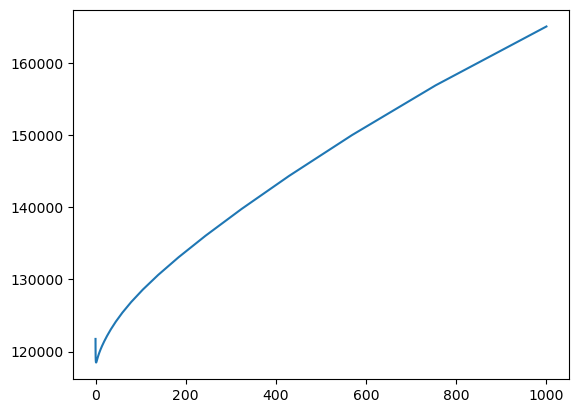

In [31]:
# λ vs MSE
import matplotlib.pyplot as plt
plt.plot(alphas, mse_list)

Text(0, 0.5, 'test MSE')

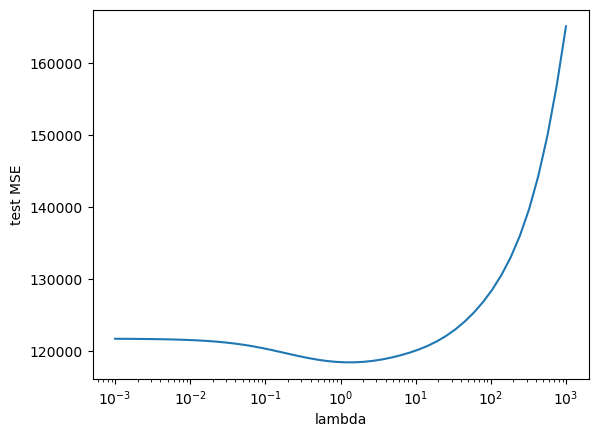

In [32]:
plt.plot(alphas, mse_list)
plt.xscale('log')
plt.xlabel('lambda')
plt.ylabel('test MSE')

Text(0, 0.5, 'standardized coefficients')

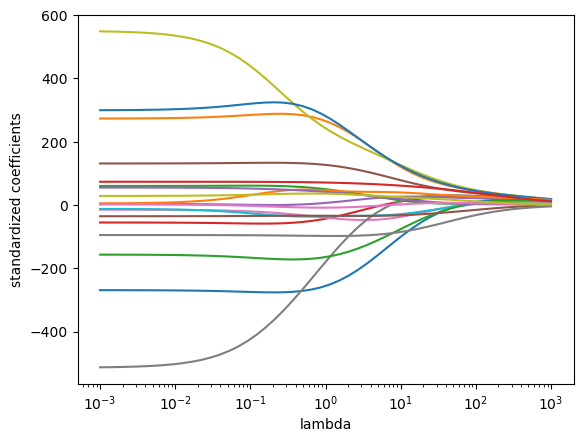

In [33]:
plt.plot(alphas, coefs)
plt.xscale('log')
plt.xlabel('lambda')
plt.ylabel('standardized coefficients')

## Lasso

In [34]:
df = pd.read_csv("../data/Hitters.csv")
# 欠損値対応
df.dropna(inplace=True)
# データの準備
y_col = 'Salary'
X = df.loc[:, df.columns!=y_col]
y = df[y_col]
# 標準化のために数値カラムのリストを作成
numeric_cols = X.select_dtypes(include=np.number).columns.to_list()
# ダミー変数 （数値カラム作成の後)
X = pd.get_dummies(X, drop_first=True, dtype=float)
# hold-out
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)
# 標準化
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [55]:
from sklearn.linear_model import LassoLars
# 内部の計算方法をLARS（最小角回帰）に変えることで、4000兆の暴走を物理的に防ぎます
# alphaのスケールが通常のLassoと異なるため、資料と同じ数値を出すために調整します
lasso = LassoLars(alpha=1.0) 
lasso.fit(X_train_scaled, y_train)

y_pred = lasso.predict(X_test_scaled)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
print(mse)
print(mae)

117700.97235234112
250.2483725110727


In [56]:
# 各特徴量の名前と、計算された係数（重み）を並べて表示する
print(pd.Series(lasso.coef_, index=X.columns))

AtBat         -264.119688
Hits           267.585667
HmRun           42.974932
Runs           -33.631983
RBI              7.477399
Walks          125.159731
Years          -29.676320
CAtBat        -237.517818
CHits          328.335782
CHmRun          -4.057473
CRuns          260.035964
CRBI             0.000000
CWalks        -161.422384
PutOuts         71.016784
Assists         40.360694
Errors         -30.341588
League_N         0.000000
Division_W     -47.804973
NewLeague_N     13.960085
dtype: float64


In [57]:
lasso.coef_

array([-264.11968849,  267.58566737,   42.97493164,  -33.63198289,
          7.47739922,  125.1597307 ,  -29.67631955, -237.51781823,
        328.3357817 ,   -4.05747337,  260.03596396,    0.        ,
       -161.42238379,   71.01678406,   40.36069405,  -30.34158811,
          0.        ,  -47.80497275,   13.96008502])

In [58]:
ridge.coef_

array([-255.99352472,  265.41620796,   49.85450911,  -43.4415344 ,
          6.40827279,  126.64463957,  -39.99788141, -180.02267219,
        242.39467113,  -36.09606293,  281.13852012,   46.31799934,
       -164.64027314,   70.88806172,   41.295514  ,  -34.06922615,
         -8.54724705,  -97.91075067,   35.72441367])

In [59]:
lr.coef_

array([-269.10981701,  272.90887884,   59.97669544,  -55.37512444,
          3.61504229,  131.08295524,  -14.78202567, -514.20110584,
        550.22369897,  -12.29554582,  299.04286135,    4.60615938,
       -156.78117836,   73.32237801,   54.94973217,  -35.64306984,
          1.59251626,  -95.02251105,   28.46798552])

## 様々なλでのLasso

In [95]:
from sklearn.linear_model import Lasso
alphas = np.logspace(-3, 3)
mse_list = []
coefs = []
for alpha in alphas:
    model = Lasso(alpha)
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    mse = mean_squared_error(y_test, y_pred)
    mse_list.append(mse)
    coefs.append(model.coef_)

/opt/conda/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.919e+08, tolerance: 3.232e+03
  model = cd_fast.enet_coordinate_descent(
/opt/conda/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.918e+08, tolerance: 3.232e+03
  model = cd_fast.enet_coordinate_descent(
/opt/conda/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.918e+08, tolerance: 3.232e

Text(0, 0.5, 'test MSE')

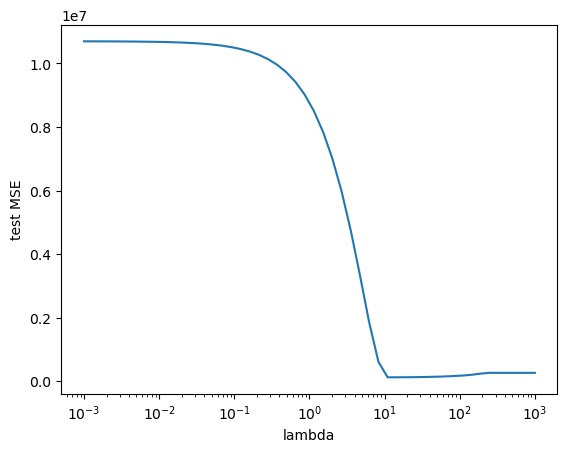

In [96]:
plt.plot(alphas, mse_list)
plt.xscale('log')
plt.xlabel('lambda')
plt.ylabel('test MSE')

In [97]:
model.intercept_

np.float64(520.4853750000001)

Text(0, 0.5, 'standardized coefficients')

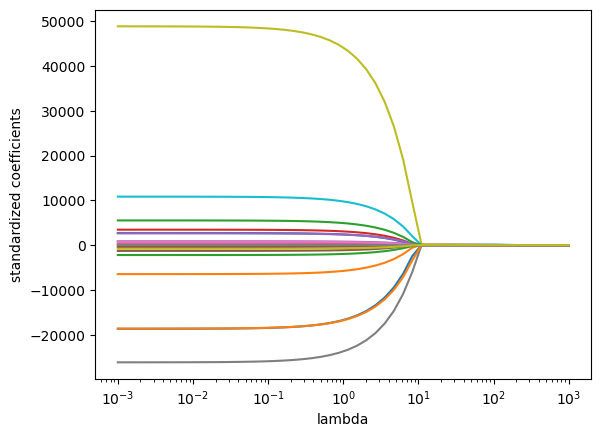

In [98]:
plt.plot(alphas, coefs)
plt.xscale('log')
plt.xlabel('lambda')
plt.ylabel('standardized coefficients')

In [99]:
alphas[np.argmin(mse_list)]

np.float64(10.985411419875572)

In [100]:
np.min(mse_list)

np.float64(125486.37501772147)

In [101]:
lasso = LassoLars(alphas[np.argmin(mse_list)]) 
lasso.fit(X_train, y_train)

,"alpha alpha: float, default=1.0Constant that multiplies the penalty term. Defaults to 1.0.``alpha = 0`` is equivalent to an ordinary least square, solvedby :class:`LinearRegression`. For numerical reasons, using``alpha = 0`` with the LassoLars object is not advised and youshould prefer the LinearRegression object.",np.float64(10.985411419875572)
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto false, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"verbose verbose: bool or int, default=FalseSets the verbosity amount.",False
,"precompute precompute: bool, 'auto' or array-like, default='auto'Whether to use a precomputed Gram matrix to speed upcalculations. If set to ``'auto'`` let us decide. The Grammatrix can also be passed as argument.",'auto'
,"max_iter max_iter: int, default=500Maximum number of iterations to perform.",500
,"eps eps: float, default=np.finfo(float).epsThe machine-precision regularization in the computation of theCholesky diagonal factors. Increase this for very ill-conditionedsystems. Unlike the ``tol`` parameter in some iterativeoptimization-based algorithms, this parameter does not controlthe tolerance of the optimization.",np.float64(2....049250313e-16)
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"fit_path fit_path: bool, default=TrueIf ``True`` the full path is stored in the ``coef_path_`` attribute.If you compute the solution for a large problem or many targets,setting ``fit_path`` to ``False`` will lead to a speedup, especiallywith a small alpha.",True
,"positive positive: bool, default=FalseRestrict coefficients to be >= 0. Be aware that you might want toremove fit_intercept which is set True by default.Under the positive restriction the model coefficients will not convergeto the ordinary-least-squares solution for small values of alpha.Only coefficients up to the smallest alpha value (``alphas_[alphas_ >0.].min()`` when fit_path=True) reached by the stepwise Lars-Lassoalgorithm are typically in congruence with the solution of thecoordinate descent Lasso estimator.",False
,"jitter jitter: float, default=NoneUpper bound on a uniform noise parameter to be added to the`y` values, to satisfy the model's assumption ofone-at-a-time computations. Might help with stability... versionadded:: 0.23",None
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for jittering. Pass an intfor reproducible output across multiple function calls.See :term:`Glossary `. Ignored if `jitter` is None... versionadded:: 0.23",None


In [102]:
lasso.coef_

array([-1.78024960e+00,  5.64506983e+00,  4.72315538e+00, -1.68537733e+00,
        6.81580562e-01,  6.06328859e+00,  0.00000000e+00, -2.75493129e-01,
        1.04717866e+00,  1.84611662e-02,  9.82517826e-01, -6.46086154e-02,
       -5.99715358e-01,  2.61516746e-01,  3.26952533e-01, -4.18083770e+00,
        0.00000000e+00, -4.76107418e+01,  0.00000000e+00])

In [103]:
X_train.columns

Index(['AtBat', 'Hits', 'HmRun', 'Runs', 'RBI', 'Walks', 'Years', 'CAtBat',
       'CHits', 'CHmRun', 'CRuns', 'CRBI', 'CWalks', 'PutOuts', 'Assists',
       'Errors', 'League_N', 'Division_W', 'NewLeague_N'],
      dtype='str')

In [104]:
pd.DataFrame({'coef': lasso.coef_, 'column_name': X_train.columns})

,coef,column_name
0,-1.780250,AtBat
1,5.645070,Hits
2,4.723155,HmRun
3,-1.685377,Runs
4,0.681581,RBI
5,6.063289,Walks
6,0.000000,Years
7,-0.275493,CAtBat
8,1.047179,CHits
9,0.018461,CHmRun


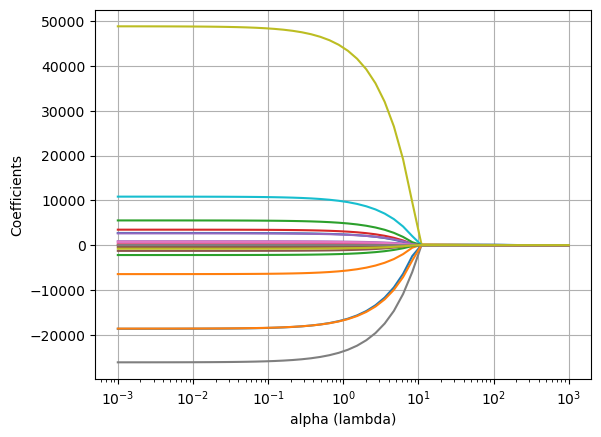

In [105]:
plt.plot(alphas, coefs)
plt.xscale('log')
plt.xlabel('alpha (lambda)')
plt.ylabel('Coefficients')
plt.grid(True)
plt.show()

In [106]:
# alphaを大きめ（10.0など）に設定して学習
test_model = Lasso(alpha=10.0)
test_model.fit(X_train_scaled, y_train)

# 係数を確認（今度こそドバッと0になっているはずです！）
print(pd.Series(test_model.coef_, index=X.columns))

AtBat            -0.000000
Hits             -0.000000
HmRun             0.000000
Runs              0.000000
RBI               0.000000
Walks            72.172776
Years            44.684560
CAtBat        -2167.731727
CHits          2311.241402
CHmRun          172.389842
CRuns             0.000000
CRBI           -133.071575
CWalks            0.000000
PutOuts          57.744784
Assists          48.049888
Errors           -9.660636
League_N          1.683794
Division_W      -33.470759
NewLeague_N       0.000000
dtype: float64


/opt/conda/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.267e+07, tolerance: 3.232e+03
  model = cd_fast.enet_coordinate_descent(


In [109]:
alphas[np.argmin(mse_list)]
np.min(mse_list)

np.float64(125486.37501772147)

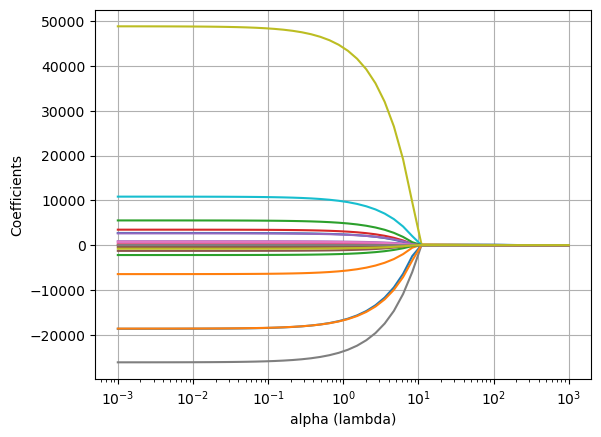

In [107]:
plt.plot(alphas, coefs)
plt.xscale('log')
plt.xlabel('alpha (lambda)')
plt.ylabel('Coefficients')
plt.grid(True)
plt.show()

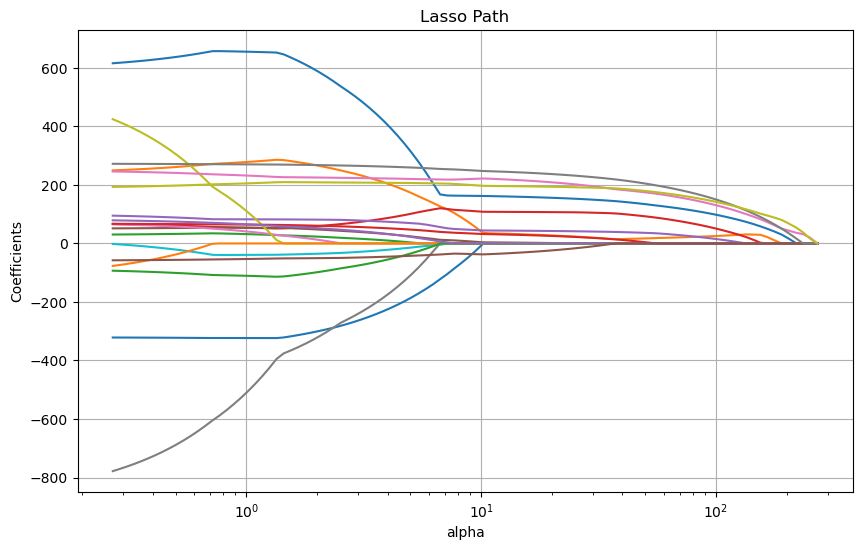

In [113]:
import matplotlib.pyplot as plt
from sklearn.linear_model import lasso_path

# 1. 正しい標準化データの準備（数値列だけを標準化）
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

# 2. lasso_path関数を使って、数学的に正確な軌跡を計算する
# (これを使うと内部で自動的に最適なalphaの範囲を計算してくれます)
alphas_path, coefs_path, _ = lasso_path(X_train_scaled, y_train)

# 3. プロット（横軸を -log10(alpha) にすると、右にいくほどペナルティが弱くなります）
# 通常のalpha軸にしたい場合は、下の「#別パターン」を使ってください
plt.figure(figsize=(10, 6))
plt.plot(alphas_path, coefs_path.T)
plt.xscale('log')
plt.xlabel('alpha')
plt.ylabel('Coefficients')
plt.title('Lasso Path')
plt.grid(True)
plt.show()

Lassoを利用する具体的な実務の流れ\
実務でLassoを使うときは、「なんとなくこの辺」と手動で決めるのではなく、「予測精度（MSE）」と「特徴量の削減（スパース性）」のバランスが一番良いポイントを数学的に決定します。\
\
ステップ1：Lasso Path（グラフ）で全体の傾向を掴む【完了】
まさに今やっていただいたステップです。
目的：alpha を大きくしたときに、どの変数から順番に消えて（0になって）いき、どの変数が最後までしぶとく残るのか（重要な変数なのか）を視覚的に把握します。\
\
ステップ2：交差検証（Cross-Validation）で「最適なalpha」を自動決定する
手動で「10くらいかな？」と決める代わりに、データを5個や10個のグループに分割してテストを繰り返し、「最も予測エラー（MSE）が小さくなる神バランスの alpha」をコンピュータに自動で見つけさせます。
\
Pythonでは LassoCV という専用の便利なクラスが用意されています。

In [114]:
from sklearn.linear_model import LassoCV

# 交差検証（CV）を使って、最も予測精度の高くなるalphaを自動探索
# cv=5 はデータを5分割して検証するという意味
lasso_cv = LassoCV(alphas=np.logspace(-3, 3), cv=5, max_iter=100000)
lasso_cv.fit(X_train_scaled, y_train)

# 最適と判定された alpha の値を出力
print(f"最適なalpha: {lasso_cv.alpha_}")

最適なalpha: 10.985411419875572


ステップ3：選ばれた alpha で係数を確認し、特徴量を選別する\
LassoCV が教えてくれた最高の alpha を使って、最終的な係数を確認します。

In [116]:
# 最適なalphaでの各特徴量の係数を確認
best_coefs = pd.Series(lasso_cv.coef_, index=X.columns)

# 0 にならずに生き残った（重要な）特徴量だけを表示
print("--- 生き残った特徴量 ---")
print(best_coefs[best_coefs != 0])

# 0 になって落とされた特徴量を表示
print("\n--- カットされた特徴量 ---")
print(best_coefs[best_coefs == 0].index.tolist())

--- 生き残った特徴量 ---
Hits           86.606006
HmRun           0.321888
RBI             8.543648
Walks          48.870418
CHits         135.496097
CRuns          37.562870
PutOuts        50.725690
Errors        -16.332813
Division_W    -60.055866
dtype: float64

--- カットされた特徴量 ---
['AtBat', 'Runs', 'Years', 'CAtBat', 'CHmRun', 'CRBI', 'CWalks', 'Assists', 'League_N', 'NewLeague_N']


ステップ4：ビジネスや次の分析へ活かす\
ここでLassoの「スパース性」の本当のメリットを刈り取ります。\
\
モデルの解釈・説明が楽になる：「19個も変数があると上司やクライアントに説明しづらいが、Lassoが重要な5個に絞ってくれたので、『この5つの指標だけ見ればOKです』と言える」\
\
データの収集コストを削る：0になった特徴量は、極論「今後はもう集めなくていいデータ」です。アンケート項目を減らしたり、システムのデータ保持容量を削減したりできます。

In [117]:
# 1. LassoCVが選んだ最適なalpha（約10.985）を使って最終モデルを構築
final_model = Lasso(alpha=lasso_cv.alpha_)
final_model.fit(X_train_scaled, y_train)

# 2. テストデータを使って予測
y_pred_final = final_model.predict(X_test_scaled)

# 3. 予測精度の評価（MSE と MAE）
from sklearn.metrics import mean_absolute_error, mean_squared_error

final_mse = mean_squared_error(y_test, y_pred_final)
final_mae = mean_absolute_error(y_test, y_pred_final)

print(f"特徴量削減後のテストMSE: {final_mse:.2f}")
print(f"特徴量削減後のテストMAE: {final_mae:.2f}")

# (参考) Ridgeのときの精度を覚えているか確認するために、並べて比較すると面白いです！

特徴量削減後のテストMSE: 126790.24
特徴量削減後のテストMAE: 240.40


/opt/conda/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.802e+03, tolerance: 3.232e+03
  model = cd_fast.enet_coordinate_descent(


In [119]:
# ElasticNetの解決策：
#「じゃあ、RidgeとLassoのペナルティをブレンドして、いいとこ取りをしよう！」と生まれたのがElasticNetです。
#関連性の高いグループ（例：通算成績のグループ）を、Lassoのようにどれか1つだけ残して他を消滅させるのではなく、グループ全体を緩やかに残しつつ、本当に不要なノイズだけをきれいに 0 に落とすという、実務で最もバランスが良いとされる挙動をしてくれます。
from sklearn.linear_model import ElasticNetCV

# l1_ratio は 1 に近いほどLasso寄り、0 に近いほどRidge寄りになります
# 複数の比率を試して、一番良いブレンド具合を自動で探します
elastic_cv = ElasticNetCV(
    alphas=np.logspace(-3, 3), 
    l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 0.99], 
    cv=5, 
    max_iter=100000
)
elastic_cv.fit(X_train_scaled, y_train)

# 最適なパラメータの出力
print(f"最適なalpha: {elastic_cv.alpha_:.3f}")
print(f"最適なブレンド比率 (l1_ratio): {elastic_cv.l1_ratio_}") 
print("※1.0に近いほどLasso（0にする力）の性質が強く出ています")

# テストデータでの予測と精度評価
y_pred_elastic = elastic_cv.predict(X_test_scaled)
elastic_mse = mean_squared_error(y_test, y_pred_elastic)
elastic_mae = mean_absolute_error(y_test, y_pred_elastic)

print(f"\nElasticNetのテストMSE: {elastic_mse:.2f}")
print(f"ElasticNetのテストMAE: {elastic_mae:.2f}")

# 生き残った特徴量の数を確認
active_features = np.sum(elastic_cv.coef_ != 0)
print(f"\n生き残った特徴量の数: {active_features} / 19個")

最適なalpha: 10.985
最適なブレンド比率 (l1_ratio): 0.99
※1.0に近いほどLasso（0にする力）の性質が強く出ています

ElasticNetのテストMSE: 126736.22
ElasticNetのテストMAE: 239.37

生き残った特徴量の数: 11 / 19個
